In [1]:
import xarray as xr
import numpy as np
import earthaccess
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import xarray as xr
import matplotlib as mpl
import matplotlib.colors as colors
from matplotlib import animation
from scipy.ndimage import gaussian_filter1d
from nasa_pace_data_reader import L1, plot
import glob, os, re

### Download Data

In [2]:
auth = earthaccess.login(persist=True)   

In [3]:
results = earthaccess.search_data(
    short_name="PACE_OCI_L1B_SCI",
    temporal=("2025-07-11T20:55:00", "2025-07-11T21:20:00"),     
    count=1
)

In [5]:
files = earthaccess.download(results, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L1B_SCI")

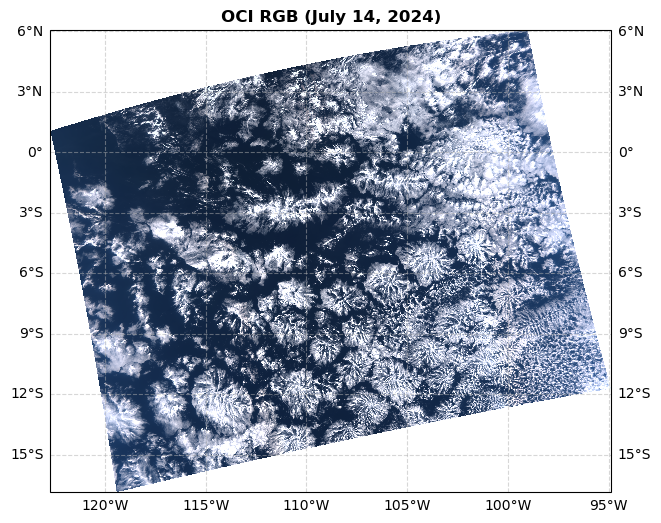

In [7]:
path = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L1B_SCI/PACE_OCI.20240714T201640.L1B.V3.nc"

obs = xr.open_dataset(path, group = 'observation_data')
geo = xr.open_dataset(path, group = 'geolocation_data')
view = xr.open_dataset(path, group = 'sensor_band_parameters')

data = xr.merge((obs, geo))

rgb = np.zeros((1710, 1272, 3))

blue = data['rhot_blue'][64,:,:]
red = data['rhot_red'][33,:,:]
green = data['rhot_blue'][92,:,:]

factor = 0.5    #0.85
rgb[:,:,0]= red[:,:]/factor
rgb[:,:,1]= green[:,:]/factor
rgb[:,:,2]= blue[:,:]/factor

rgb[ rgb > 1 ] = 1.0
rgb[ rgb < 0 ] = 0.0

fig, ax = plt.subplots(1, 1, figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()})

ax.pcolormesh(data.longitude, data.latitude, rgb, transform=ccrs.PlateCarree(), shading="nearest", rasterized=True)
ax.set_aspect("equal")
# ax.set_extent([-10, -5, -5, -10], crs=ccrs.PlateCarree())
ax.set_title('OCI RGB (July 14, 2024)', fontsize=12, fontweight = 'bold')
# ax.add_feature(cfeature.LAND)
# ax.add_feature(cfeature.OCEAN)
# ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.coastlines(color="grey")
ax.gridlines(draw_labels={"bottom": True, "left": True, "right": True}, linestyle="--", alpha=0.5)

# plt.savefig("OCI_RGB.png", dpi=500, bbox_inches="tight")
plt.show()  